# Manuscript Results

Figures and statistics reported in the main manuscript.

In [2]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import urllib3
import matplotlib.pyplot as plt
from matplotlib import gridspec
from matplotlib.patches import Rectangle, Patch
from scipy.stats import mannwhitneyu

from utils import central_results
from utils.get_pids_with_feature import get_pids_with_feature

urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

# Initialize output directories and load core dataframes
central_results.create_plot_dirs()
engine, users_df, user_messages_df, ai_messages_df, surveys_df, included_user_ids, pid_map, pid_info = central_results.load_data()

# Shared plotting config
TOPIC_COLOR_MAP = central_results.TOPIC_COLOR_MAP
PLOTS = central_results.PLOTS
SVG_OUTPUT_DIR = central_results.SVG_OUTPUT_DIR
PNG_OUTPUT_DIR = central_results.PNG_OUTPUT_DIR

COLORS = ['#012a4a', '#013a63', '#01497c', '#014f86', '#2a6f97',
          '#2c7da0', '#468faf', '#61a5c2', '#89c2d9', '#a9d6e5']

new_topic_color_map = {
    "seizure": COLORS[8],
    "sleep":   COLORS[6],
    "spike":   COLORS[4],
    "general chat": COLORS[2],
}

# Aliases for the helpers used below
compute_interaction_volume              = central_results.compute_interaction_volume
topic_classification_user_queries       = central_results.topic_classification_user_queries
compute_system_response_latency_by_type = central_results.compute_system_response_latency_by_type
compute_user_response_latency_by_category = central_results.compute_user_response_latency_by_category


Database engine created successfully.
Data loaded successfully.


## Patient response: surveys and event prompts

Stacked bar chart combining survey response rates (morning / afternoon / evening) with seizure- and spike-event verification rates (yes / unsure / no / no response).

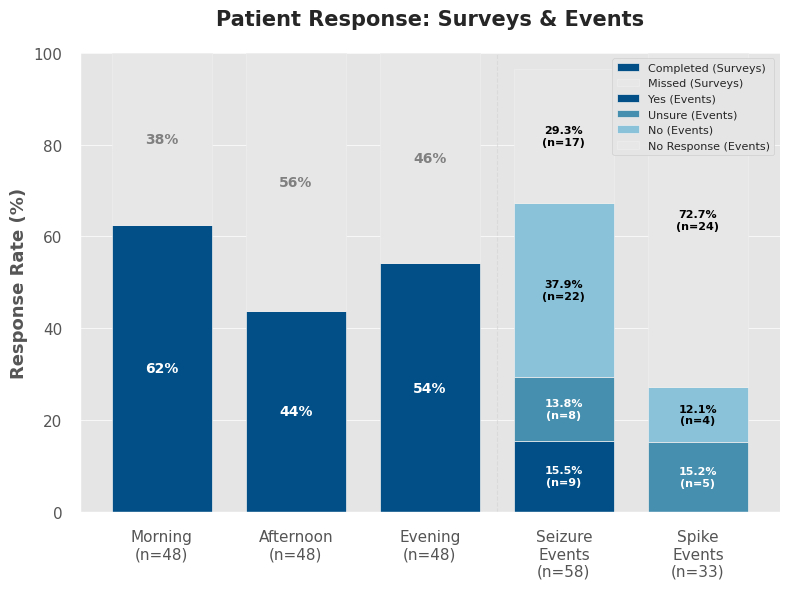

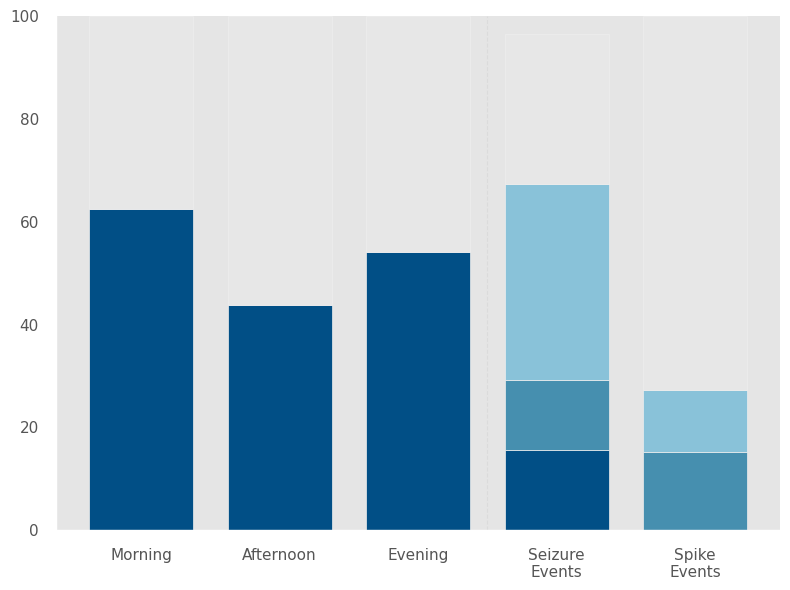


=== Patient Response Summary ===

Surveys by Time of Day:
  Morning: 30/48 (62.5%)
  Afternoon: 21/48 (43.8%)
  Evening: 26/48 (54.2%)

Event Verification:

  Seizure Events (n=58):
    Yes:         9 (16%)
    Unsure:      8 (14%)
    No:          22 (38%)
    No Response: 17 (29%)

  Spike Events (n=33):
    Yes:         0 (0%)
    Unsure:      5 (15%)
    No:          4 (12%)
    No Response: 24 (73%)


In [11]:
# Cohort-level statistics
summary_df, overall_survey_rate = central_results.compute_summary_statistics(
    users_df, user_messages_df, ai_messages_df, surveys_df, pid_info)
clinical_df, overall_seizure_rate = central_results.compute_seizure_statistics(
    engine, users_df, included_user_ids, summary_df)
spike_summary_df, overall_spike_rate = central_results.compute_spike_statistics(
    engine, users_df, included_user_ids, summary_df)

survey_time_stats        = central_results.compute_survey_response_by_time_of_day(engine, included_user_ids)
event_verification_stats = central_results.compute_event_verification_stats(engine, included_user_ids)

# Adjustment: remove 2 misclassified seizure events
event_verification_stats['seizure_events']['unsure'] -= 2

COMBINED_FIGSIZE = (8, 6)

# Labeled plot
fig, ax = plt.subplots(figsize=COMBINED_FIGSIZE)

categories      = ['Morning', 'Afternoon', 'Evening', 'Seizure\nEvents', 'Spike\nEvents']
survey_periods  = ['morning', 'afternoon', 'evening']
event_types     = ['seizure_events', 'spike_events']

survey_color        = COLORS[3]
survey_missed_color = '#E7E7E7'
event_colors = {
    'yes':         '#014f86',
    'unsure':      '#468faf',
    'no':          '#89c2d9',
    'no_response': '#E7E7E7',
}

x = np.arange(len(categories))
width = 0.75

# Survey bars (positions 0-2): completed (color) stacked under missed (gray)
for i, period in enumerate(survey_periods):
    stats = survey_time_stats[period]
    total = stats['total']
    if total > 0:
        completed_pct = stats['completed'] / total * 100
        missed_pct    = stats['missed']    / total * 100

        ax.bar(x[i], completed_pct, width, color=survey_color)
        ax.bar(x[i], missed_pct,    width, bottom=completed_pct, color=survey_missed_color)

        if completed_pct > 5:
            ax.text(x[i], completed_pct/2, f'{completed_pct:.0f}%', ha='center', va='center',
                    color='white', fontweight='bold', fontsize=10)
        if missed_pct > 5:
            ax.text(x[i], completed_pct + missed_pct/2, f'{missed_pct:.0f}%', ha='center', va='center',
                    color='gray', fontweight='bold', fontsize=10)

# Event bars (positions 3-4): yes / unsure / no / no_response stacked
for idx, event_type in enumerate(event_types):
    i = idx + 3
    stats = event_verification_stats[event_type]
    total = stats['total']

    if total > 0:
        yes_pct         = stats['yes']         / total * 100
        unsure_pct      = stats['unsure']      / total * 100
        no_pct          = stats['no']          / total * 100
        no_response_pct = stats['no_response'] / total * 100

        bottom = 0
        for category, pct, count in [
            ('yes',         yes_pct,         stats['yes']),
            ('unsure',      unsure_pct,      stats['unsure']),
            ('no',          no_pct,          stats['no']),
            ('no_response', no_response_pct, stats['no_response']),
        ]:
            ax.bar(x[i], pct, width, bottom=bottom, color=event_colors[category])
            if pct > 5:
                ax.text(x[i], bottom + pct/2, f'{pct:.1f}%\n(n={count})', ha='center', va='center',
                        color='white' if category in ['yes', 'unsure'] else 'black',
                        fontweight='bold', fontsize=8)
            bottom += pct

# Total-count annotations under each x-tick
totals = ([survey_time_stats[p]['total'] for p in survey_periods] +
          [event_verification_stats[et]['total'] for et in event_types])
ax.set_xticks(x)
ax.set_xticklabels([f'{cat}\n(n={t})' for cat, t in zip(categories, totals)], fontsize=11)

ax.set_ylabel('Response Rate (%)', fontsize=13, fontweight='bold')
ax.set_title('Patient Response: Surveys & Events', fontsize=15, fontweight='bold', pad=20)
ax.set_ylim(0, 100)
ax.tick_params(axis='y', labelsize=11)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_bounds(0, 100)

ax.yaxis.grid(True, linestyle='-', linewidth=0.5)
ax.xaxis.grid(False)
ax.set_axisbelow(True)

# Visual separator between survey and event groups
ax.axvline(x=2.5, color='lightgray', linestyle='--', linewidth=0.8, alpha=0.6)

legend_elements = [
    Patch(facecolor=survey_color,                 label='Completed (Surveys)'),
    Patch(facecolor=survey_missed_color,          label='Missed (Surveys)'),
    Patch(facecolor=event_colors['yes'],          label='Yes (Events)'),
    Patch(facecolor=event_colors['unsure'],       label='Unsure (Events)'),
    Patch(facecolor=event_colors['no'],           label='No (Events)'),
    Patch(facecolor=event_colors['no_response'],  label='No Response (Events)'),
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=8, framealpha=0.9)

plt.tight_layout()
fig.savefig(os.path.join(PLOTS["conversations_svg"], "patient_response_combined.svg"), format="svg", bbox_inches="tight")
fig.savefig(os.path.join(PLOTS["conversations_png"], "patient_response_combined.png"), dpi=300, bbox_inches="tight")
plt.show()

# Clean variant (no labels, no legend) for figure assembly
fig_clean, ax_clean = plt.subplots(figsize=COMBINED_FIGSIZE)

for i, period in enumerate(survey_periods):
    stats = survey_time_stats[period]
    total = stats['total']
    if total > 0:
        completed_pct = stats['completed'] / total * 100
        missed_pct    = stats['missed']    / total * 100
        ax_clean.bar(x[i], completed_pct, width, color=survey_color)
        ax_clean.bar(x[i], missed_pct,    width, bottom=completed_pct, color=survey_missed_color)

for idx, event_type in enumerate(event_types):
    i = idx + 3
    stats = event_verification_stats[event_type]
    total = stats['total']
    if total > 0:
        yes_pct         = stats['yes']         / total * 100
        unsure_pct      = stats['unsure']      / total * 100
        no_pct          = stats['no']          / total * 100
        no_response_pct = stats['no_response'] / total * 100

        bottom = 0
        for category, pct in [('yes', yes_pct), ('unsure', unsure_pct),
                              ('no', no_pct), ('no_response', no_response_pct)]:
            ax_clean.bar(x[i], pct, width, bottom=bottom, color=event_colors[category])
            bottom += pct

ax_clean.set_xticks(x)
ax_clean.set_xticklabels(categories, fontsize=11)
ax_clean.set_ylim(0, 100)
ax_clean.tick_params(axis='y', labelsize=11)
ax_clean.set_ylabel('')
ax_clean.set_title('')
ax_clean.spines['top'].set_visible(False)
ax_clean.spines['right'].set_visible(False)
ax_clean.spines['left'].set_bounds(0, 100)
ax_clean.yaxis.grid(False)
ax_clean.xaxis.grid(False)
ax_clean.axvline(x=2.5, color='lightgray', linestyle='--', linewidth=0.8, alpha=0.5)

plt.tight_layout()
fig_clean.savefig(os.path.join(PLOTS["conversations_svg"], "patient_response_combined_clean.svg"), format="svg", bbox_inches="tight")
fig_clean.savefig(os.path.join(PLOTS["conversations_png"], "patient_response_combined_clean.png"), dpi=300, bbox_inches="tight")
plt.show()

# Numeric summary
print("\n=== Patient Response Summary ===")
print("\nSurveys by Time of Day:")
for period, cat in zip(survey_periods, ['Morning', 'Afternoon', 'Evening']):
    s = survey_time_stats[period]
    if s['total'] > 0:
        print(f"  {cat}: {s['completed']}/{s['total']} ({s['completed']/s['total']*100:.1f}%)")

print("\nEvent Verification:")
for event_type, label in zip(event_types, ['Seizure Events', 'Spike Events']):
    s = event_verification_stats[event_type]
    print(f"\n  {label} (n={s['total']}):")
    if s['total'] > 0:
        print(f"    Yes:         {s['yes']} ({s['yes']/s['total']*100:.0f}%)")
        print(f"    Unsure:      {s['unsure']} ({s['unsure']/s['total']*100:.0f}%)")
        print(f"    No:          {s['no']} ({s['no']/s['total']*100:.0f}%)")
        print(f"    No Response: {s['no_response']} ({s['no_response']/s['total']*100:.0f}%)")


## System response latency by message type

Per-message latency (AI response time) split by handler: **General Chat** vs **Data Agent**. Mann–Whitney U test with bootstrapped rank-biserial effect size and 95 % CI.



Statistical Test: Mann-Whitney U Test
Comparing: General Chat vs Data Agent latencies

Test Statistic: 1086.00
P-value: 9.892767985183092e-21

Result: SIGNIFICANT difference (p < 0.05)
Conclusion: There is a statistically significant difference between
           General Chat and Data Agent response latencies.

Statistical summary: median difference 6.747, IQR 2.532-5.115, 95%CI [4.990,8.651]; p=9.89e-21, r=0.86

System Response Latency by Type

General Chat:
  Count:  337
  Mean:   3.20 s
  Median: 1.95 s
  IQR:    2.53 s (Q1: 1.57, Q3: 4.11)
  Std:    3.19 s
  Min:    0.61 s
  Max:    23.68 s

Data Agent:
  Count:  45
  Mean:   9.43 s
  Median: 8.69 s
  IQR:    5.11 s (Q1: 6.67, Q3: 11.79)
  Std:    3.64 s
  Min:    3.71 s
  Max:    20.79 s

Saved plot to plots/conversations_svg/system_response_latency_by_type.svg
Saved plot to plots/conversations_png/system_response_latency_by_type.png


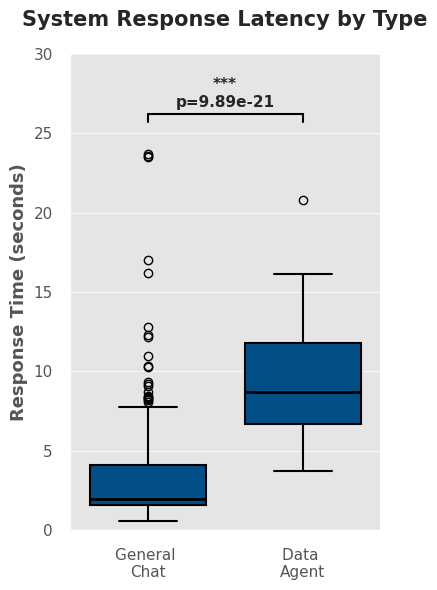


Saved blank plot to plots/conversations_svg/system_response_latency_by_type_blank.svg
Saved blank plot to plots/conversations_png/system_response_latency_by_type_blank.png


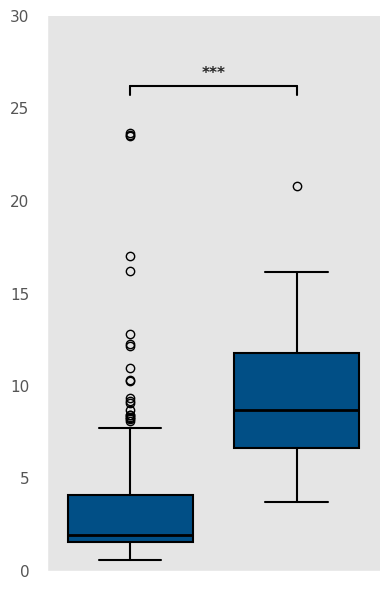

In [12]:
# Compute per-message system latencies
latency_df = compute_system_response_latency_by_type(engine, included_user_ids)

general_chat_data = latency_df[latency_df['category'] == 'General Chat']['response_time_seconds']
data_agent_data   = latency_df[latency_df['category'] == 'Data Agent']['response_time_seconds']

p_value = None
significance_text = ""

if len(general_chat_data) > 0 and len(data_agent_data) > 0:
    # Mann-Whitney U (two-sided, non-parametric)
    statistic, p_value = mannwhitneyu(general_chat_data, data_agent_data, alternative='two-sided')

    print("\n" + "=" * 50)
    print("\nStatistical Test: Mann-Whitney U Test")
    print(f"Comparing: General Chat vs Data Agent latencies")
    print(f"\nTest Statistic: {statistic:.2f}")
    print(f"P-value: {p_value}")

    alpha = 0.05
    if p_value < alpha:
        print(f"\nResult: SIGNIFICANT difference (p < {alpha})")
        print("Conclusion: There is a statistically significant difference between")
        print("           General Chat and Data Agent response latencies.")
    else:
        print(f"\nResult: NO significant difference (p >= {alpha})")
        print("Conclusion: There is no statistically significant difference between")
        print("           General Chat and Data Agent response latencies.")

    # Median difference + bootstrapped 95% CI of the median difference
    n1 = len(general_chat_data)
    n2 = len(data_agent_data)
    r = 1 - (2 * statistic) / (n1 * n2)
    
    median_diff = data_agent_data.median() - general_chat_data.median()
    iqr_g = general_chat_data.quantile(0.75) - general_chat_data.quantile(0.25)
    iqr_d = data_agent_data.quantile(0.75) - data_agent_data.quantile(0.25)

    np.random.seed(42)
    n_bootstraps = 10000
    boot_diffs = []
    g_arr = general_chat_data.values
    d_arr = data_agent_data.values
    for _ in range(n_bootstraps):
        boot_g = np.random.choice(g_arr, size=n1, replace=True)
        boot_d = np.random.choice(d_arr, size=n2, replace=True)
        boot_diffs.append(np.median(boot_d) - np.median(boot_g))

    ci_lower = np.percentile(boot_diffs, 2.5)
    ci_upper = np.percentile(boot_diffs, 97.5)

    p_formatted = f"{p_value:.3f}" if p_value >= 0.001 else f"{p_value:.2e}"
    print(f"\nStatistical summary: median difference {median_diff:.3f}, IQR {iqr_g:.3f}-{iqr_d:.3f}, 95%CI [{ci_lower:.3f},{ci_upper:.3f}]; p={p_formatted}, r={r:.2f}")
    print("=" * 50)

    if   p_value < 0.001: significance_text = "***"
    elif p_value < 0.01:  significance_text = "**"
    elif p_value < 0.05:  significance_text = "*"
    else:                 significance_text = "n.s."

# Descriptive statistics
print("\nSystem Response Latency by Type")
for category in ['General Chat', 'Data Agent']:
    cat_data = latency_df[latency_df['category'] == category]['response_time_seconds']
    if len(cat_data) > 0:
        q1 = cat_data.quantile(0.25)
        q3 = cat_data.quantile(0.75)
        iqr = q3 - q1
        print(f"\n{category}:")
        print(f"  Count:  {len(cat_data)}")
        print(f"  Mean:   {cat_data.mean():.2f} s")
        print(f"  Median: {cat_data.median():.2f} s")
        print(f"  IQR:    {iqr:.2f} s (Q1: {q1:.2f}, Q3: {q3:.2f})")
        print(f"  Std:    {cat_data.std():.2f} s")
        print(f"  Min:    {cat_data.min():.2f} s")
        print(f"  Max:    {cat_data.max():.2f} s")

# Labeled boxplot
fig, ax = plt.subplots(figsize=(4, 6))

bp = ax.boxplot(
    [general_chat_data, data_agent_data],
    positions=[0, 1],
    widths=0.75,
    patch_artist=True,
    boxprops=dict(linewidth=1.5),
    medianprops=dict(color='black', linewidth=2),
    whiskerprops=dict(linewidth=1.5),
    capprops=dict(linewidth=1.5),
)
bp['boxes'][0].set_facecolor(COLORS[3])
bp['boxes'][1].set_facecolor(COLORS[3])

# Significance bracket
if p_value is not None:
    y_max   = max(general_chat_data.max(), data_agent_data.max())
    y_range = ax.get_ylim()[1] - ax.get_ylim()[0]
    bracket_height = y_max + 0.1 * y_range

    x1, x2 = 0, 1
    y = bracket_height
    h = 0.02 * y_range
    ax.plot([x1, x2], [y, y], 'k-', linewidth=1.5)
    ax.plot([x1, x1], [y, y - h], 'k-', linewidth=1.5)
    ax.plot([x2, x2], [y, y - h], 'k-', linewidth=1.5)

    text_label = (f"{significance_text}\np={p_value:.3f}" if significance_text == "n.s."
                  else f"{significance_text}\np={p_value:.2e}")
    ax.text((x1 + x2) / 2, y + 0.01 * y_range, text_label,
            ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_ylabel('Response Time (seconds)', fontsize=13, fontweight='bold')
ax.set_title('System Response Latency by Type', fontsize=15, fontweight='bold', pad=20)
ax.set_xticks([0, 1])
ax.set_xticklabels(['General \nChat', 'Data \nAgent'], fontsize=11)
ax.tick_params(axis='y', labelsize=11)
ax.set_ylim(0, 30)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_bounds(0, 30)
ax.yaxis.grid(True, linestyle='-', linewidth=0.5)
ax.xaxis.grid(False)
ax.set_axisbelow(True)

plt.tight_layout()
svg_path = os.path.join(SVG_OUTPUT_DIR, "system_response_latency_by_type.svg")
png_path = os.path.join(PNG_OUTPUT_DIR, "system_response_latency_by_type.png")
fig.savefig(svg_path, format="svg", bbox_inches='tight')
fig.savefig(png_path, format="png", bbox_inches='tight', dpi=300)
print(f"\nSaved plot to {svg_path}")
print(f"Saved plot to {png_path}")
plt.show()

# Clean variant (no x-tick labels) with significance only
fig, ax = plt.subplots(figsize=(4, 6))
bp = ax.boxplot(
    [general_chat_data, data_agent_data],
    positions=[0, 1],
    widths=0.75,
    patch_artist=True,
    boxprops=dict(linewidth=1.5),
    medianprops=dict(color='black', linewidth=2),
    whiskerprops=dict(linewidth=1.5),
    capprops=dict(linewidth=1.5),
)
bp['boxes'][0].set_facecolor(COLORS[3])
bp['boxes'][1].set_facecolor(COLORS[3])

if p_value is not None:
    y_max   = max(general_chat_data.max(), data_agent_data.max())
    y_range = ax.get_ylim()[1] - ax.get_ylim()[0]
    bracket_height = y_max + 0.1 * y_range
    x1, x2 = 0, 1
    y = bracket_height
    h = 0.02 * y_range
    ax.plot([x1, x2], [y, y], 'k-', linewidth=1.5)
    ax.plot([x1, x1], [y, y - h], 'k-', linewidth=1.5)
    ax.plot([x2, x2], [y, y - h], 'k-', linewidth=1.5)
    text_label = significance_text if significance_text != "n.s." else "n.s."
    ax.text((x1 + x2) / 2, y + 0.01 * y_range, text_label,
            ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_ylim(0, 30)
ax.tick_params(axis='y', labelsize=11)
ax.set_xticks([])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_bounds(0, 30)
ax.yaxis.grid(False)
ax.xaxis.grid(False)

plt.tight_layout()
svg_path_blank = os.path.join(SVG_OUTPUT_DIR, "system_response_latency_by_type_blank.svg")
png_path_blank = os.path.join(PNG_OUTPUT_DIR, "system_response_latency_by_type_blank.png")
fig.savefig(svg_path_blank, format="svg", bbox_inches='tight', transparent=True)
fig.savefig(png_path_blank, format="png", bbox_inches='tight', transparent=True, dpi=300)
print(f"\nSaved blank plot to {svg_path_blank}")
print(f"Saved blank plot to {png_path_blank}")
plt.show()


## Message-type distribution

Single donut split into patient-originated message topics (green) and AI-originated message categories (blue), with shading rank-ordered within each half by count.

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


[Topics] Patient query distribution:
{'seizure': 24, 'sleep': 15, 'spike': 8, 'general chat': 360}


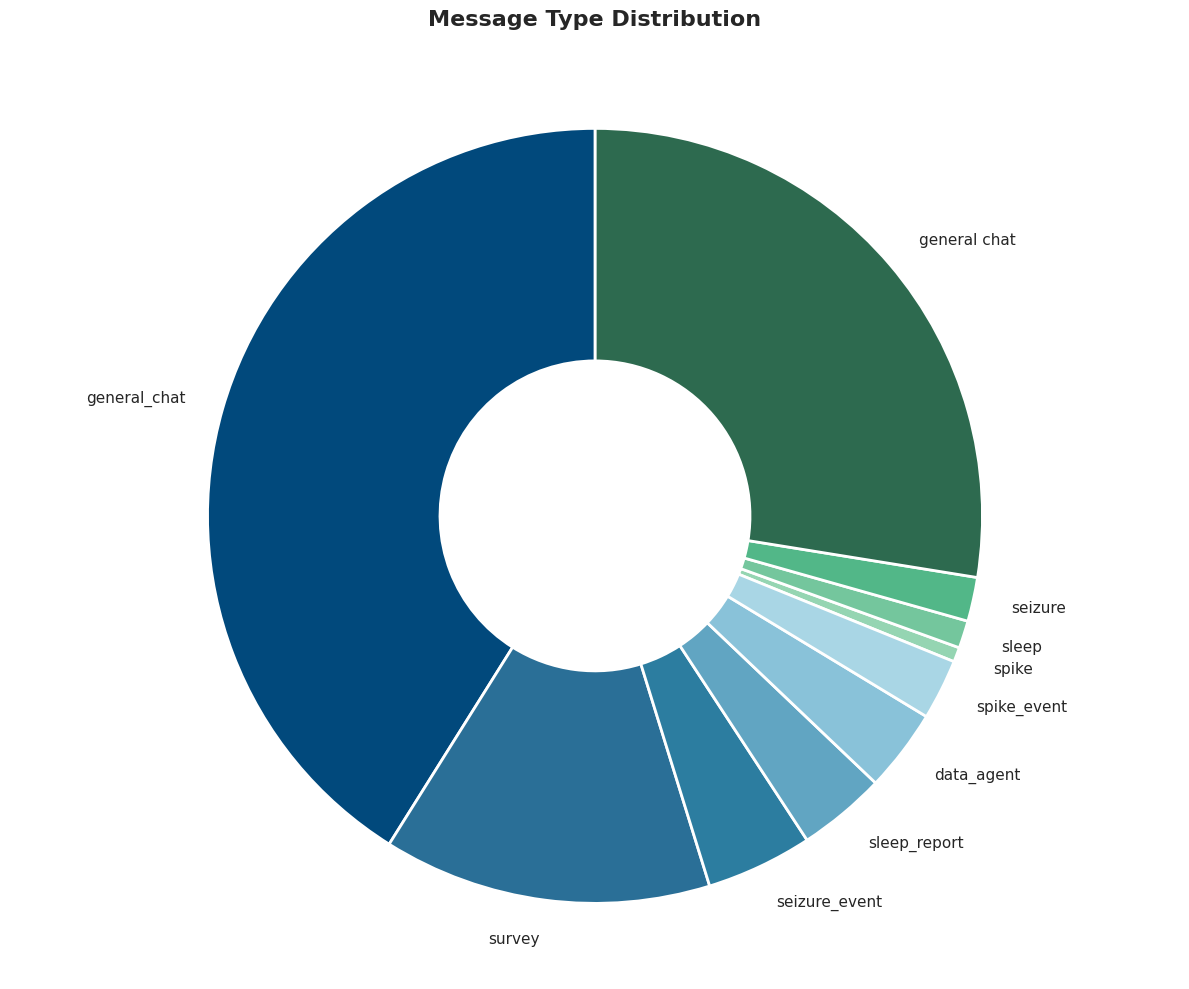


Category                            Count      Percentage

                      PATIENT MESSAGES                      
------------------------------------------------------------
spike                                   8           0.61%
sleep                                  15           1.15%
seizure                                24           1.84%
general chat                          360          27.54%
------------------------------------------------------------
Subtotal                              407          31.14%

                        AI MESSAGES                         
------------------------------------------------------------
general_chat                          537          41.09%
survey                                179          13.70%
seizure_event                          58           4.44%
sleep_report                           48           3.67%
data_agent                             45           3.44%
spike_event                            33           2.

In [5]:
BLUE_COLORS  = ['#01497c', '#014f86', '#2a6f97', '#2c7da0', '#468faf', '#61a5c2', '#89c2d9', '#a9d6e5']
GREEN_COLORS = ['#2d6a4f', '#40916c', '#52b788', '#74c69d', '#95d5b2']

plt.style.use('ggplot')
plt.rcParams['legend.fontsize'] = 12

patient_count = len(user_messages_df)

# Patient queries grouped by inferred topic, ascending by count
patient_topic_counts = topic_classification_user_queries(engine, included_user_ids).sort_values(ascending=True)
patient_types = patient_topic_counts.index.tolist()
patient_sizes = patient_topic_counts.values.tolist()

# AI messages grouped into simplified categories (descending)
ai_query = '''
SELECT
    CASE
        WHEN message_type = 'scheduled' THEN 'survey'
        WHEN message_type = 'normal' AND message_info IN ('follow_up_intro', 'follow_up_1', 'follow_up_2', 'follow_up_3') THEN 'general_chat'
        WHEN message_type = 'normal' THEN 'general_chat'
        WHEN message_type = 'seizure_response_confirmation' THEN 'general_chat'
        WHEN message_type = 'spike_response_confirmation'   THEN 'general_chat'
        WHEN message_type = 'seizure_detection' THEN 'seizure_event'
        WHEN message_type = 'spike_detection'   THEN 'spike_event'
        ELSE message_type
    END AS simplified_message_type,
    COUNT(*) AS count
FROM ai_messages
GROUP BY simplified_message_type
ORDER BY count DESC
'''
ai_type_counts = pd.read_sql_query(ai_query, engine)
ai_types = ai_type_counts['simplified_message_type'].tolist()
ai_sizes = ai_type_counts['count'].tolist()
ai_count = int(ai_type_counts['count'].sum())

category_names = patient_types + ai_types
category_sizes = patient_sizes + ai_sizes

# Rotate the chart so the patient/AI boundary sits at 12 o'clock
total_count        = sum(category_sizes)
patient_total      = sum(patient_sizes)
patient_percentage = patient_total / total_count
startangle = 90 - (patient_percentage * 360)

# Assign colors by within-group size rank: largest = darkest
PATIENT_COLORS = GREEN_COLORS
AI_COLORS      = BLUE_COLORS

colors = []
if patient_sizes:
    patient_ranks = np.argsort(np.argsort(patient_sizes))
    for rank in patient_ranks:
        color_idx = len(PATIENT_COLORS) - 1 - int(rank * (len(PATIENT_COLORS) - 1) / max(len(patient_sizes) - 1, 1))
        colors.append(PATIENT_COLORS[color_idx])
if ai_sizes:
    ai_ranks = np.argsort(np.argsort(ai_sizes))
    for rank in ai_ranks:
        color_idx = len(AI_COLORS) - 1 - int(rank * (len(AI_COLORS) - 1) / max(len(ai_sizes) - 1, 1))
        colors.append(AI_COLORS[color_idx])

fig, ax = plt.subplots(figsize=(12, 10))
ax.axis('equal')
wedges, texts = ax.pie(category_sizes, labels=category_names,
                       labeldistance=1.1, colors=colors,
                       textprops={'fontsize': 11},
                       startangle=startangle)
plt.setp(wedges, width=0.6, edgecolor='white', linewidth=2)

plt.title('Message Type Distribution', fontsize=16, weight='bold', pad=20)
plt.tight_layout()
plt.savefig('message_donut.png', dpi=300, bbox_inches='tight')
plt.savefig('message_donut.svg', format="svg", bbox_inches='tight')
plt.show()

# Detailed numeric breakdown
print(f"\n{'=' * 60}")
print(f"{'Category':<30} {'Count':>10} {'Percentage':>15}")
print(f"{'=' * 60}")

print(f"\n{'PATIENT MESSAGES':^60}")
print(f"{'-' * 60}")
for name, size in zip(patient_types, patient_sizes):
    print(f"{name:<30} {size:>10,} {(size / total_count) * 100:>14.2f}%")
print(f"{'-' * 60}")
print(f"{'Subtotal':<30} {patient_total:>10,} {(patient_total / total_count) * 100:>14.2f}%")

print(f"\n{'AI MESSAGES':^60}")
print(f"{'-' * 60}")
for name, size in zip(ai_types, ai_sizes):
    print(f"{name:<30} {size:>10,} {(size / total_count) * 100:>14.2f}%")
print(f"{'-' * 60}")
print(f"{'Subtotal':<30} {ai_count:>10,} {(ai_count / total_count) * 100:>14.2f}%")

print(f"\n{'=' * 60}")
print(f"{'TOTAL':<30} {total_count:>10,} {100.00:>14.2f}%")
print(f"{'=' * 60}")


In [6]:
# Simplified AI message type counts (the same categorization as the donut)
query = '''
SELECT
    CASE
        WHEN message_type = 'scheduled' THEN 'survey'
        WHEN message_type = 'normal' AND message_info IN ('follow_up_intro', 'follow_up_1', 'follow_up_2', 'follow_up_3') THEN 'general_chat'
        WHEN message_type = 'normal' THEN 'general_chat'
        WHEN message_type = 'seizure_response_confirmation' THEN 'general_chat'
        WHEN message_type = 'spike_response_confirmation'   THEN 'general_chat'
        WHEN message_type = 'seizure_detection' THEN 'seizure_event'
        WHEN message_type = 'spike_detection'   THEN 'spike_event'
        ELSE message_type
    END AS simplified_message_type,
    COUNT(*) AS count
FROM ai_messages
GROUP BY simplified_message_type
ORDER BY count DESC
'''

simplified_counts = pd.read_sql_query(query, engine)
print("Total AI message count:", int(simplified_counts["count"].sum()), "\n")
print("AI message type counts:")
print(simplified_counts)

print("\n\nBreakdown as dictionary:")
result_dict = dict(zip(simplified_counts['simplified_message_type'], simplified_counts['count']))
print(result_dict)


Total AI message count: 900 

AI message type counts:
  simplified_message_type  count
0            general_chat    537
1                  survey    179
2           seizure_event     58
3            sleep_report     48
4              data_agent     45
5             spike_event     33


Breakdown as dictionary:
{'general_chat': 537, 'survey': 179, 'seizure_event': 58, 'sleep_report': 48, 'data_agent': 45, 'spike_event': 33}


## User response latency by category

Cumulative bar chart of patient response times to system messages, faceted by category (general chat, surveys, seizure events, spike events). Solid bars are the leading time bin; later bins are stacked above with dashed borders.

Found 13 matches in sparcnet_annotations
Found 28 additional matches in seizure_annotations
Category             Time Bin   Percentage   Cumulative  
------------------------------------------------------------
--- General Chat ---
                     0-1min         22.36%      22.36%
                     1-2min         10.14%      32.51%
                     2-5min          6.42%      38.92%
                     5-10min         2.69%      41.61%
                     10-30min        2.48%      44.10%
                     30-60min        1.04%      45.13%
                     1-2hr           1.86%      47.00%
                     2-6hr           5.59%      52.59%
                     6-12hr          4.76%      57.35%
                     12-24hr         8.70%      66.05%
--- Surveys ---
                     0-1min         16.11%      16.11%
                     1-2min          1.34%      17.45%
                     2-5min          3.36%      20.81%
                     5-10min         

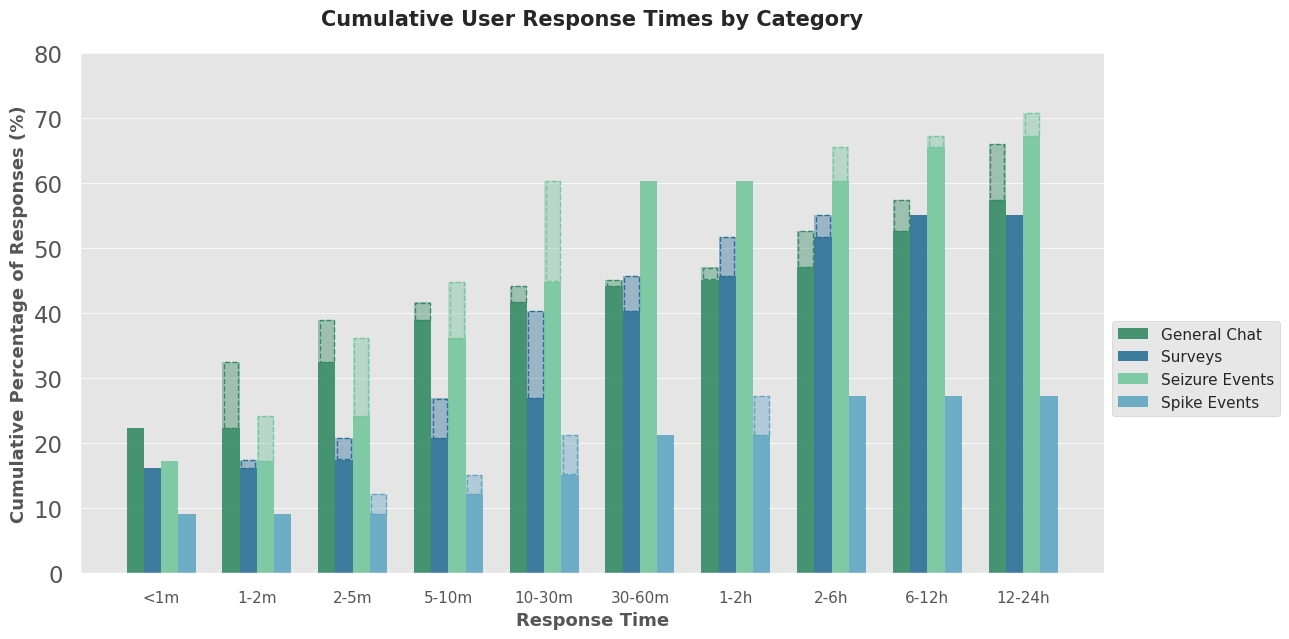

In [7]:
compute_user_response_latency_by_category = central_results.compute_user_response_latency_by_category
user_response_df, excluded_df = compute_user_response_latency_by_category(engine, included_user_ids)

# Time-bin ordering (excludes >24 h and no-response)
bin_order  = ['0-1min', '1-2min', '2-5min', '5-10min', '10-30min', '30-60min',
              '1-2hr', '2-6hr', '6-12hr', '12-24hr']
bin_labels = ['<1m', '1-2m', '2-5m', '5-10m', '10-30m', '30-60m',
              '1-2h', '2-6h', '6-12h', '12-24h']

category_map = {
    'general_chat':  'General Chat',
    'survey':        'Surveys',
    'seizure_event': 'Seizure Events',
    'spike_event':   'Spike Events',
}
category_colors = {
    'general_chat':  '#358A64',
    'survey':        '#2A6F97',
    'seizure_event': '#74C69D',
    'spike_event':   '#61A5C2',
}
categories = ['general_chat', 'survey', 'seizure_event', 'spike_event']

percentage_data = {}
cumulative_data = {}
for category in categories:
    cat_df = user_response_df[user_response_df['category'] == category]
    total_count = len(cat_df)
    if total_count == 0:
        continue

    bin_counts = []
    for bin_name in bin_order:
        count = len(cat_df[cat_df['time_bin'] == bin_name])
        bin_counts.append((count / total_count) * 100)
    percentage_data[category] = bin_counts

    running_sum = 0
    cumulative_pct = []
    for pct in bin_counts:
        running_sum += pct
        cumulative_pct.append(running_sum)
    cumulative_data[category] = cumulative_pct

# Numeric summary
print(f"{'Category':<20} {'Time Bin':<10} {'Percentage':<12} {'Cumulative':<12}")
print("-" * 60)
for category in categories:
    if category not in percentage_data:
        continue
    print(f"--- {category_map.get(category, category)} ---")
    for i, bin_name in enumerate(bin_order):
        print(f"{'':<20} {bin_name:<10} {percentage_data[category][i]:>9.2f}% {cumulative_data[category][i]:>10.2f}%")
print("-" * 60)
print()

# Plot
fig, ax = plt.subplots(figsize=(13, 6.5))

x = np.arange(len(bin_order))
bar_width = 0.18
offsets = np.linspace(-1.5 * bar_width, 1.5 * bar_width, len(categories))
inset = 0.015  # inset for the dashed increment-border

for idx, category in enumerate(categories):
    if category not in cumulative_data:
        continue

    cumulative  = cumulative_data[category]
    incremental = percentage_data[category]

    for i in range(len(bin_order)):
        base = cumulative[i] - incremental[i]  # cumulative up to previous bin

        if base > 0:
            ax.bar(x[i] + offsets[idx], base, bar_width,
                   color=category_colors[category], alpha=0.9, edgecolor='none')

        if i == 0:
            # First (leading) bin: solid color, used for legend handle
            ax.bar(x[i] + offsets[idx], incremental[i], bar_width,
                   bottom=base, label=category_map[category],
                   color=category_colors[category], alpha=0.9, edgecolor='none')
        else:
            # Later bins: lighter fill with dashed outline
            ax.bar(x[i] + offsets[idx], incremental[i], bar_width,
                   bottom=base, color=category_colors[category],
                   alpha=0.4, edgecolor='none')

            if incremental[i] > 0.5:
                rect = Rectangle(
                    (x[i] + offsets[idx] - bar_width/2 + inset, base + inset),
                    bar_width - 2 * inset,
                    incremental[i] - 2 * inset,
                    fill=False, edgecolor=category_colors[category],
                    linewidth=1.0, linestyle='--', zorder=10,
                )
                ax.add_patch(rect)

ax.set_xlabel('Response Time', fontsize=13, fontweight='bold')
ax.set_ylabel('Cumulative Percentage of Responses (%)', fontsize=13, fontweight='bold')
ax.set_title('Cumulative User Response Times by Category', fontsize=15, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(bin_labels, fontsize=11)
ax.set_ylim(0, 80)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.yaxis.grid(True, linestyle='-', linewidth=0.5)
ax.xaxis.grid(False)
ax.set_axisbelow(True)
ax.legend(loc='upper left', bbox_to_anchor=(1, 0.5), fontsize=11, framealpha=0.9)

plt.tight_layout()
if 'PLOTS' in globals():
    plt.savefig(os.path.join(PLOTS["conversations_svg"], "user_response_times_cumulative.svg"),
                dpi=300, bbox_inches="tight", transparent=True)
    plt.savefig(os.path.join(PLOTS["conversations_png"], "user_response_times_png.png"),
                dpi=200, bbox_inches="tight", transparent=True)
plt.show()


## Data agent routing and response accuracy

Two-bar chart: (1) **Router accuracy** — fraction of user messages routed to the correct handler (data agent vs general chat), and (2) **Data agent response accuracy** — fraction of correctly routed data-agent requests whose response was factually correct.

Routing/accuracy labels live in `incorrectly_routed_ai_messages.csv` and `data_agent_accuracy.csv` (not included in this public release — see `README.md`).

Total general chat requests (users 008+): 39
DATA AGENT SYSTEM PERFORMANCE

--- Router Performance ---
Total routing decisions: 78
  - Data agent requests:  39
  - General chat requests: 39

Correctly routed: 70
  - DA requests → DA: 38
  - GC requests → GC: 32

Routing errors: 8
  - DA requests → GC (incorrect): 1
  - GC requests → DA (incorrect): 7

Router Accuracy: 89.7%

--- Data Agent Response Accuracy ---
Total correctly routed DA requests: 38
Correct responses:   35
Incorrect responses: 3
Data Agent Accuracy: 92.1%


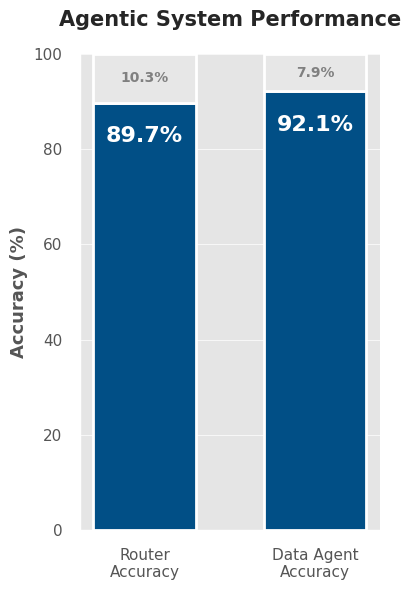

,Metric,Correct,Incorrect,Total,Accuracy (%)
0,Router Accuracy,70,8,78,89.7%
1,Data Agent Accuracy,35,3,38,92.1%


In [8]:
# Load human-labeled routing and response-accuracy CSVs
incorrectly_routed_df    = pd.read_csv('incorrectly_routed_ai_messages.csv')
da_accuracy_df           = pd.read_csv('data_agent_accuracy.csv')
user_data_agent_requests = pd.read_csv('user_data_agent_requests.csv')
ai_data_agent_responses  = pd.read_csv('ai_data_agent_responses.csv')

# Router was only active for users 008+ (user_id >= 8)
router_active_user_ids = [uid for uid in included_user_ids if uid >= 8]

# Data-agent requests (total, from human-labeled CSV)
total_da_requests = len(user_data_agent_requests)

# General-chat requests in the same period (from the DB)
gc_messages_df = pd.read_sql(
    '''
    SELECT id, user_id, content, message_type, timestamp
    FROM user_messages
    WHERE user_id = ANY(%(user_ids)s)
      AND message_type IS NOT NULL
      AND 'general_chat' = ANY(message_type)
    ''',
    engine, params={'user_ids': router_active_user_ids},
)
total_gc_requests = len(gc_messages_df)
print(f"Total general chat requests (users 008+): {total_gc_requests}")

# Routing errors
routed_to_general_chat   = len(incorrectly_routed_df[incorrectly_routed_df['Routing_Error_Type'] == 'should_be_data_agent'])
routed_to_da_incorrectly = len(incorrectly_routed_df[incorrectly_routed_df['Routing_Error_Type'] == 'should_be_general_chat'])
total_routing_errors     = routed_to_general_chat + routed_to_da_incorrectly

total_routing_decisions = total_da_requests + total_gc_requests
correctly_routed_da     = total_da_requests - routed_to_general_chat
correctly_routed_gc     = total_gc_requests - routed_to_da_incorrectly
correctly_routed        = correctly_routed_da + correctly_routed_gc
router_accuracy         = (correctly_routed / total_routing_decisions) * 100
router_error            = 100 - router_accuracy

# Data-agent response accuracy
total_correctly_routed_da = len(da_accuracy_df)
correct_responses         = len(da_accuracy_df[da_accuracy_df['DA_Accuracy'] == 'correct'])
incorrect_responses       = len(da_accuracy_df[da_accuracy_df['DA_Accuracy'] == 'incorrect'])
da_accuracy               = (correct_responses / total_correctly_routed_da) * 100
da_error                  = 100 - da_accuracy

# Numeric summary
print("=" * 70)
print("DATA AGENT SYSTEM PERFORMANCE")
print("=" * 70)
print(f"\n--- Router Performance ---")
print(f"Total routing decisions: {total_routing_decisions}")
print(f"  - Data agent requests:  {total_da_requests}")
print(f"  - General chat requests: {total_gc_requests}")
print(f"\nCorrectly routed: {correctly_routed}")
print(f"  - DA requests → DA: {correctly_routed_da}")
print(f"  - GC requests → GC: {correctly_routed_gc}")
print(f"\nRouting errors: {total_routing_errors}")
print(f"  - DA requests → GC (incorrect): {routed_to_general_chat}")
print(f"  - GC requests → DA (incorrect): {routed_to_da_incorrectly}")
print(f"\nRouter Accuracy: {router_accuracy:.1f}%")

print(f"\n--- Data Agent Response Accuracy ---")
print(f"Total correctly routed DA requests: {total_correctly_routed_da}")
print(f"Correct responses:   {correct_responses}")
print(f"Incorrect responses: {incorrect_responses}")
print(f"Data Agent Accuracy: {da_accuracy:.1f}%")
print("=" * 70)

# Stacked-bar plot: accuracy (colored) + error (gray)
fig, ax = plt.subplots(figsize=(4, 6))

categories  = ['Router\nAccuracy', 'Data Agent\nAccuracy']
accuracies  = [router_accuracy, da_accuracy]
errors      = [router_error,    da_error]
bar_color   = COLORS[3]
error_color = '#E7E7E7'

x = np.arange(len(categories))
width = 0.6

bars = ax.bar(x, accuracies, width, color=bar_color, edgecolor='white', linewidth=2)
ax.bar(x, errors, width, bottom=accuracies, color=error_color, edgecolor='white', linewidth=2)

for i, (bar, acc, err) in enumerate(zip(bars, accuracies, errors)):
    ax.text(x[i], acc - 5, f'{acc:.1f}%', ha='center', va='top',
            fontsize=16, fontweight='bold', color='white')
    if err > 5:
        ax.text(x[i], acc + err / 2, f'{err:.1f}%', ha='center', va='center',
                fontsize=10, fontweight='bold', color='gray')

ax.set_ylabel('Accuracy (%)', fontsize=13, fontweight='bold')
ax.set_ylim(0, 100)
ax.set_title('Agentic System Performance', fontsize=15, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(categories, fontsize=11)
ax.tick_params(axis='y', labelsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_bounds(0, 100)
ax.yaxis.grid(True, linestyle='-', linewidth=0.5)
ax.xaxis.grid(False)
ax.set_axisbelow(True)

plt.tight_layout()
fig.savefig(os.path.join(PLOTS["conversations_svg"], "data_agent_accuracy.svg"), format="svg", bbox_inches="tight")
fig.savefig(os.path.join(PLOTS["conversations_png"], "data_agent_accuracy.png"), dpi=300, bbox_inches="tight")
plt.show()

print()
summary_data = {
    'Metric':       ['Router Accuracy', 'Data Agent Accuracy'],
    'Correct':      [correctly_routed, correct_responses],
    'Incorrect':    [total_routing_errors, incorrect_responses],
    'Total':        [total_routing_decisions, total_correctly_routed_da],
    'Accuracy (%)': [f'{router_accuracy:.1f}%', f'{da_accuracy:.1f}%'],
}
summary_table = pd.DataFrame(summary_data)
display(summary_table)


## System Usability Scale (SUS)

Per-participant SUS scores from the exit survey, plus the cohort average. SUS is scored 0–100 by reversing even-numbered items and rescaling by 2.5. Reference thresholds: ≥ 68 above average, ≥ 80.3 "excellent".

Found 50 SUS answers from exit surveys
Users with completed exit surveys: ['011' '012' '013' '014' '016']

SYSTEM USABILITY SCALE SCORES
  011: 100.0
  012: 82.5
  013: 72.5
  014: 82.5
  016: 77.5

  Average: 83.0


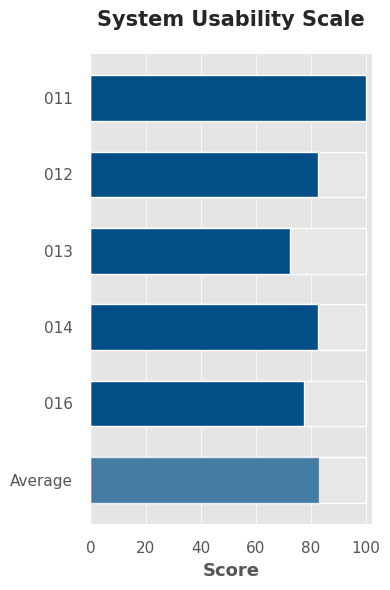

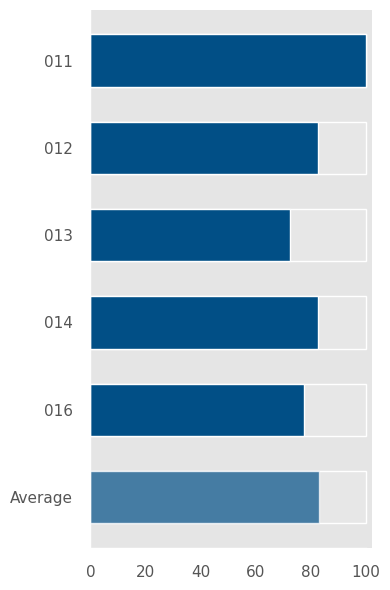

In [9]:
# Pull SUS answers from completed exit surveys
exit_survey_data = pd.read_sql(
    '''
    SELECT
        s.id     AS survey_id,
        s.user_id,
        u.username,
        s.is_completed,
        sq.question_order,
        sq.question_text,
        sa.answer_value
    FROM surveys s
    JOIN users u             ON s.user_id = u.id
    JOIN survey_answers sa   ON sa.survey_id = s.id
    JOIN survey_questions sq ON sa.question_id = sq.id
    WHERE s.survey_type = 'exit'
      AND s.is_completed = TRUE
      AND sq.construct = 'System Usability Scale'
    ORDER BY s.user_id, sq.question_order
    ''',
    engine,
)
print(f"Found {len(exit_survey_data)} SUS answers from exit surveys")
print(f"Users with completed exit surveys: {exit_survey_data['username'].unique()}")

def calculate_sus_score(answers_df):
    """Standard SUS scoring: odd items contribute (answer - 1); even items (5 - answer); sum * 2.5."""
    if len(answers_df) != 10:
        print(f"  Warning: Expected 10 questions, got {len(answers_df)}")
        return None

    answers_df = answers_df.sort_values('question_order')
    total = 0
    for _, row in answers_df.iterrows():
        q_num = row['question_order']
        try:
            answer = float(row['answer_value'])
        except (ValueError, TypeError):
            return None
        total += (answer - 1) if q_num % 2 == 1 else (5 - answer)
    return total * 2.5

# Per-participant SUS scores
sus_scores = []
for user_id in exit_survey_data['user_id'].unique():
    user_data = exit_survey_data[exit_survey_data['user_id'] == user_id]
    username  = user_data['username'].iloc[0]
    score     = calculate_sus_score(user_data)
    if score is not None:
        sus_scores.append({'user_id': user_id, 'username': username, 'label': username, 'sus_score': score})

sus_df = pd.DataFrame(sus_scores)

if len(sus_df) > 0:
    sus_df = sus_df.sort_values('username')

    print("\n" + "=" * 50)
    print("SYSTEM USABILITY SCALE SCORES")
    print("=" * 50)
    for _, row in sus_df.iterrows():
        print(f"  {row['label']}: {row['sus_score']:.1f}")
    average_sus = sus_df['sus_score'].mean()
    print(f"\n  Average: {average_sus:.1f}")
    print("=" * 50)

    # Horizontal bar plot (labeled)
    fig, ax = plt.subplots(figsize=(4, 6))

    labels = list(sus_df['label']) + ['Average']
    scores = list(sus_df['sus_score']) + [average_sus]
    y_pos  = np.arange(len(labels))
    bar_color  = COLORS[3]
    gray_color = '#E7E7E7'

    ax.barh(y_pos, [100] * len(labels), height=0.6, color=gray_color, edgecolor='white', linewidth=1)
    bars = ax.barh(y_pos, scores,       height=0.6, color=bar_color,  edgecolor='white', linewidth=1)
    bars[-1].set_alpha(0.7)  # de-emphasize the cohort average bar

    ax.set_xlabel('Score', fontsize=13, fontweight='bold')
    ax.set_title('System Usability Scale', fontsize=15, fontweight='bold', pad=20)
    ax.set_xlim(0, 102)
    ax.set_xticks([0, 20, 40, 60, 80, 100])
    ax.set_yticks(y_pos)
    ax.set_yticklabels(labels, fontsize=11)
    ax.tick_params(axis='x', labelsize=11)
    ax.invert_yaxis()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_bounds(0, 100)
    ax.xaxis.grid(True, linestyle='-', linewidth=0.5)
    ax.yaxis.grid(False)
    ax.set_axisbelow(True)

    plt.tight_layout()
    fig.savefig(os.path.join(PLOTS["conversations_svg"], "system_usability_scale.svg"), format="svg", bbox_inches="tight")
    fig.savefig(os.path.join(PLOTS["conversations_png"], "system_usability_scale.png"), dpi=300, bbox_inches="tight")
    plt.show()

    # Clean variant
    fig_clean, ax_clean = plt.subplots(figsize=(4, 6))
    ax_clean.barh(y_pos, [100] * len(labels), height=0.6, color=gray_color, edgecolor='white', linewidth=1)
    bars_clean = ax_clean.barh(y_pos, scores, height=0.6, color=bar_color, edgecolor='white', linewidth=1)
    bars_clean[-1].set_alpha(0.7)
    ax_clean.set_xlim(0, 102)
    ax_clean.set_xticks([0, 20, 40, 60, 80, 100])
    ax_clean.set_yticks(y_pos)
    ax_clean.set_yticklabels(labels, fontsize=11)
    ax_clean.tick_params(axis='x', labelsize=11)
    ax_clean.invert_yaxis()
    ax_clean.spines['top'].set_visible(False)
    ax_clean.spines['right'].set_visible(False)
    ax_clean.spines['bottom'].set_bounds(0, 100)
    ax_clean.xaxis.grid(False)
    ax_clean.yaxis.grid(False)

    plt.tight_layout()
    fig_clean.savefig(os.path.join(PLOTS["conversations_svg"], "system_usability_scale_clean.svg"), format="svg", bbox_inches="tight")
    fig_clean.savefig(os.path.join(PLOTS["conversations_png"], "system_usability_scale_clean.png"), dpi=300, bbox_inches="tight")
    plt.show()
else:
    print("No SUS scores could be calculated. Check data.")
